# Credit Card Fraud: Cost Aware Fraud Detection

**Texto Kaggle**

**Context**: It is important that credit card companies are able to recognize fraudulent credit card transactions so that customers are not charged for items that they did not purchase.

**Content**: The dataset contains transactions made by credit cards in September 2013 by European cardholders.
This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC). Confusion matrix accuracy is not meaningful for unbalanced classification.

**Link**: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("creditcard.csv")
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Exploração dos dados

### Desbalanceamento

In [9]:
# Verificando desbalanceamento
class_fraud = df["Class"].value_counts()
print(class_fraud)

print("---- \nProporção")
prop_class_fraud = df["Class"].value_counts(normalize = True)
print(prop_class_fraud)

Class
0    284315
1       492
Name: count, dtype: int64
---- 
Proporção
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


### Investigação da Fraude ao longo do tempo
* **Pergunta:** O padrão de dados hoje é o mesmo de amanhã?
* Fraude NÃO é estática. Ela evolui porque:
    * fraudadores se adaptam ao sistema
    * novos padrões de ataque surgem
    * comportamento dos clientes muda
* Consequência prática: Um modelo treinado hoje pode funcionar muito bem no passado e falhar no futuro

In [3]:
#Separar o tempo
df = df.sort_values('Time')

split = int(0.7 * len(df))
train = df.iloc[:split]
test = df.iloc[split:]

# Target Drift
train_rate = train['Class'].mean()
test_rate = test['Class'].mean()

print(f"Média de fraude no treino: {np.round(train_rate, 5)} e Média de fraude no teste: {np.round(test_rate,5)}")

Média de fraude no treino: 0.00193 e Média de fraude no teste: 0.00126


In [20]:
#Data Drift com coluna Amount
print("Resumo coluna Amount no treino")
train['Amount'].describe()

Resumo coluna Amount no treino


count    199364.000000
mean         89.771200
std         248.911638
min           0.000000
25%           5.990000
50%          23.000000
75%          79.320000
max       19656.530000
Name: Amount, dtype: float64

In [21]:
print("Resumo coluna Amount no teste")
test['Amount'].describe()

Resumo coluna Amount no teste


count    85443.000000
mean        85.032648
std        252.887772
min          0.000000
25%          5.000000
50%         20.000000
75%         72.170000
max      25691.160000
Name: Amount, dtype: float64

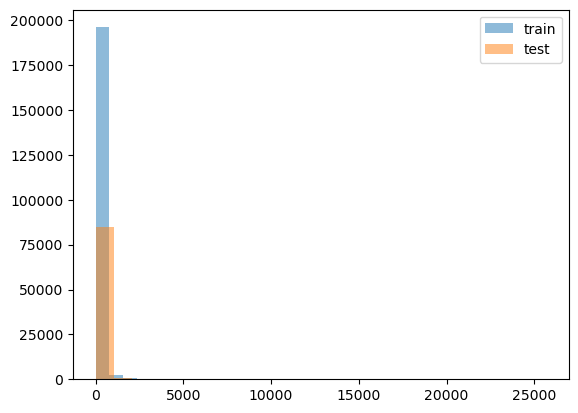

In [23]:
plt.hist(train['Amount'], bins=25, alpha=0.5, label='train')
plt.hist(test['Amount'], bins=25, alpha=0.5, label='test')
plt.legend()
plt.show()

**Comentários**
1. Treino: 0.00193 (0.193%) e Teste: 0.00126 (0.126%). A taxa de fraude caiu significativamente ($\approx$35%) do treino para o teste (Isso NÃO é ruído pequeno).
    * O modelo pode ficar descalibrado, então se você treina em um ambiente com mais fraude o modelo aprende que fraude é “mais comum”
        * no teste $\Rightarrow$ ele tende a superestimar risco
        * Resultado: mais falsos positivos (bloqueios indevidos)
        * Ideia: Comparar desempenho e perdas do modelo com diferentes separações
    * Impacto direto no seu problema de custo: custo de FP aumenta (bloqueio desnecessário) e custo de FN pode cair (menos fraude real)
        * o threshold ótimo muda com o tempo
    * **Isso pode indicar:**
        * mudança no comportamento dos fraudadores
        * mudança na política de coleta de dados
        * ou simplesmente recorte temporal não estacionário

2. No *Drift em Amount*, vemos:
    * Treino leve redução geral (transações típicas menores) e cauda mais extrema (valores máximos maiores no teste)
    * **O que isso significa na prática?** O comportamento mudou de forma não uniforme: “cliente médio” gasta menos, mas eventos extremos são maiores

3. Implicações para seu modelo
    * Modelo pode errar em extremos
        * Se no treino menos valores altos e no teste mais valores extremos $\Rightarrow$ modelo pode subestimar risco em grandes transações ou reagir mal fora da distribuição
    * Impacto no custo
        * custo = fraude * Amount. Assim, valores maiores no teste = erros ficam mais caros

    * Interação com target drift
        * Você tem menos fraudes (bom), mas valores mais extremos (ruim) $\Rightarrow$ isso pode gerar menos eventos, mas mais impacto por evento

### Verificando mudança de distribuição com Kolmogorov-Smirnov test (KS Test)
* **O que estamos investigando:** Queremos verificar se, entre treino e teste, as variáveis mudaram de distribuição. Como as V1 até V28 são componentes anonimizadas por PCA, você não interpreta o significado delas diretamente, mas ainda consegue responder:
    * a feature mudou de comportamento ao longo do tempo?
    * essa mudança é estatisticamente relevante?
    * quais variáveis parecem mais instáveis?

In [4]:
from scipy.stats import ks_2samp

# Supondo que train e test já existem
feature_cols = [col for col in df.columns if col not in ['Class']]

ks_results = []

for col in feature_cols:
    stat, pvalue = ks_2samp(train[col], test[col])
    ks_results.append({
        'feature': col,
        'ks_stat': stat,
        'pvalue': pvalue,
        'train_mean': train[col].mean(),
        'test_mean': test[col].mean(),
        'train_std': train[col].std(),
        'test_std': test[col].std()
    })

ks_df = pd.DataFrame(ks_results).sort_values(by='ks_stat', ascending=False)

print(ks_df.head(15))

   feature   ks_stat  pvalue    train_mean      test_mean     train_std  \
0     Time  1.000000     0.0  70444.416048  151675.038833  34502.988193   
3       V3  0.399748     0.0      0.320783      -0.748482      1.447531   
1       V1  0.303643     0.0     -0.105411       0.245956      1.891043   
28     V28  0.257859     0.0      0.001916      -0.004470      0.313844   
25     V25  0.232169     0.0      0.060814      -0.141897      0.491248   
15     V15  0.191524     0.0      0.084181      -0.196419      0.944587   
5       V5  0.180992     0.0     -0.112147       0.261673      1.361533   
11     V11  0.162594     0.0      0.126153      -0.294354      1.040918   
22     V22  0.153919     0.0     -0.047919       0.111809      0.691323   
4       V4  0.144490     0.0      0.075491      -0.176142      1.399229   
23     V23  0.144349     0.0     -0.015519       0.036210      0.610755   
21     V21  0.122015     0.0     -0.014674       0.034239      0.738184   
20     V20  0.107443     

In [8]:
# Primeiro vamos olhar os testes Amount, Time e top 5 ou top 10 Vs com maior ks_stat
top_drift_features = ks_df.head(10)['feature'].tolist()
print(top_drift_features)

#Amount (caso não apareça)
print("\nKS coluna Amount")
print(ks_df[ks_df['feature'] == 'Amount'])


['Time', 'V3', 'V1', 'V28', 'V25', 'V15', 'V5', 'V11', 'V22', 'V4']

KS coluna Amount
   feature   ks_stat        pvalue  train_mean  test_mean   train_std  \
29  Amount  0.029393  2.525428e-45     89.7712  85.032648  248.911638   

      test_std  
29  252.887772  


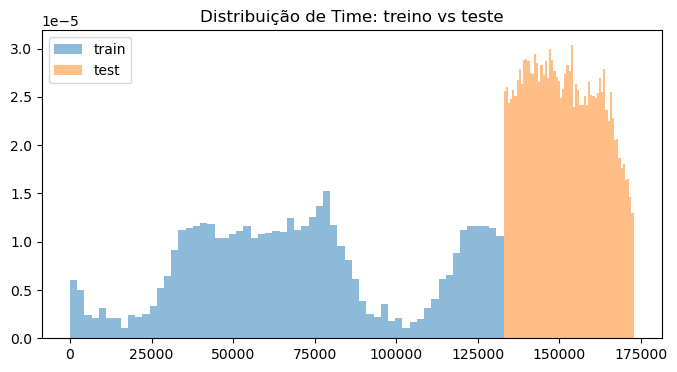

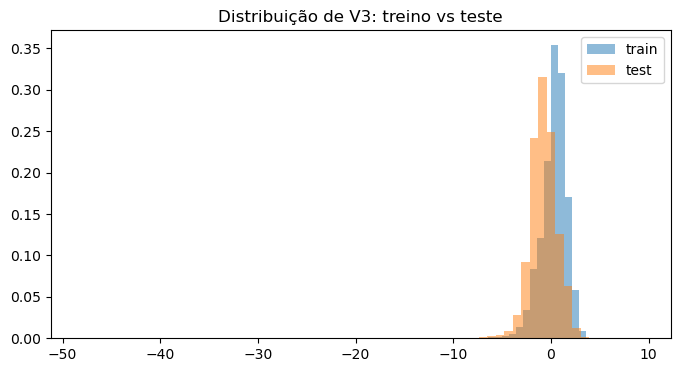

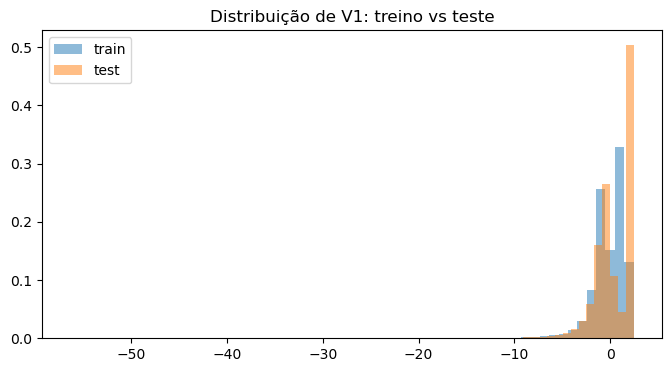

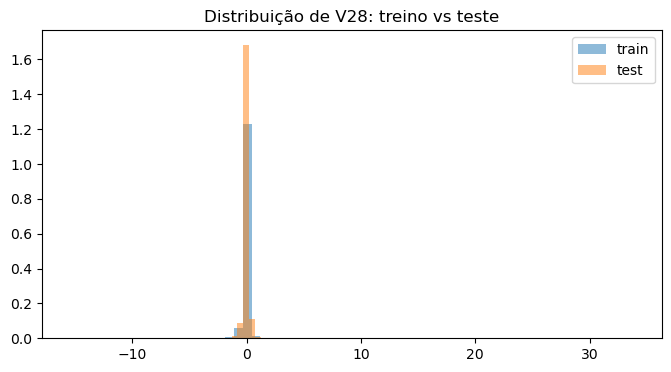

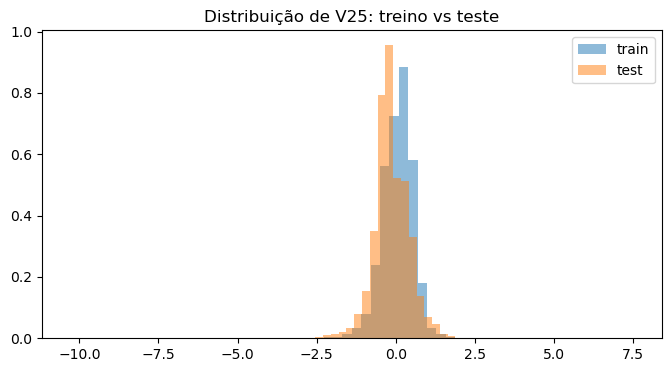

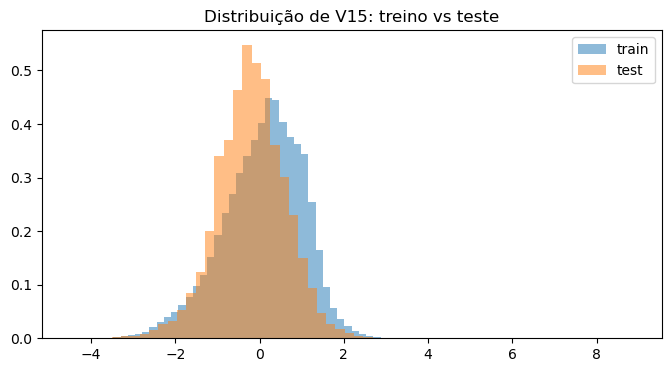

In [9]:
#Visualizar histograma das features
for col in top_drift_features[:6]:
    plt.figure(figsize=(8,4))
    plt.hist(train[col], bins=60, alpha=0.5, label='train', density=True)
    plt.hist(test[col], bins=60, alpha=0.5, label='test', density=True)
    plt.title(f'Distribuição de {col}: treino vs teste')
    plt.legend()
    plt.show()

In [11]:
#Tabela
ks_df['drift_flag_5pct'] = ks_df['pvalue'] < 0.05
ks_df['mean_diff'] = ks_df['test_mean'] - ks_df['train_mean']
ks_df['relative_std_diff'] = (ks_df['test_std'] - ks_df['train_std']) / (ks_df['train_std'] + 1e-8)

ks_df[['feature', 'ks_stat', 'pvalue', 'drift_flag_5pct', 'mean_diff', 'relative_std_diff']].head(15)

,feature,ks_stat,pvalue,drift_flag_5pct,mean_diff,relative_std_diff
0,Time,1.000000,0.0,True,81230.622785,-0.681937
3,V3,0.399748,0.0,True,-1.069265,-0.029394
1,V1,0.303643,0.0,True,0.351368,0.103908
28,V28,0.257859,0.0,True,-0.006386,0.163444
25,V25,0.232169,0.0,True,-0.202711,0.140532
15,V15,0.191524,0.0,True,-0.280600,-0.142763
5,V5,0.180992,0.0,True,0.373820,0.019560
11,V11,0.162594,0.0,True,-0.420507,-0.129584
22,V22,0.153919,0.0,True,0.159727,0.141234
4,V4,0.144490,0.0,True,-0.251633,0.028166


* **Cuidado importante** O KS test diz que a distribuição mudou, mas não diz por que mudou e se isso vai piorar o modelo

* **Interpretação**
    * **Drift forte** = combinação de: ks_stat alto, mean_diff relevante e mudança de std
    * Exemplos:
        * V3: ks_stat = 0.39 (muito alto), mean_diff = -1.07 (grande) e std ~ parecido
            * Interpretação distribuição inteira deslocou

        * V1: ks_stat = 0.30, mean_diff = +0.35 e std aumentou
            * Interpretação: mudança de posição + dispersão
        
        * V28: ks_stat = 0.25, mean_diff pequeno e std aumentou bastante
            * Interpretação: mesma média, mas mais variabilidade
         
    * **Conclusão dessa tabela**: tem drift estrutural em várias features $\Rightarrow$ não é apenas ruído, então pode impactar modelo

**Pergunta chave**: O modelo treinado no passado ainda faz sentido no futuro?

## Exploração mais avançada
Diante do cenário preciso verificar: meus dados são estáveis? posso confiar em generalização? o problema muda no tempo? **(Model Risk Analysis / Data Validation)**

* O que verificamos até aqui:
    1. O problema NÃO é estacionário
        * taxa de fraude mudou
        * várias features mudaram
        * Implicação:
            * modelo único fixo pode falhar
            * precisa considerar tempo
        
    2. Algumas features são instáveis
        * Ex: V3, V1
        * Isso levanta perguntas: o modelo depende dessas variáveis? se depende, então risco alto

    3. O risco econômico pode mudar
        * menos fraude (bom)
        * mas mudanças estruturais
        * decisão ótima pode mudar com o tempo

#### Cruzar drift com importância das features
Pergunta: As variáveis que mais mudaram são as que o modelo mais usa?

In [12]:
# Separação Treino (70%), Val (15%) e teste (15%)
df = df.sort_values('Time').reset_index(drop=True)

#separando índices
n = len(df)
train_end = int(0.70 * n)
val_end = int(0.85 * n)

train = df.iloc[:train_end]
val = df.iloc[train_end:val_end]
test = df.iloc[val_end:]

print(train.shape, val.shape, test.shape)
print(train['Class'].mean(), val['Class'].mean(), test['Class'].mean())

# Separando conjuntos
X_train = train.drop(columns=['Class'])
y_train = train['Class']

X_val = val.drop(columns=['Class'])
y_val = val['Class']

X_test = test.drop(columns=['Class'])
y_test = test['Class']

(199364, 31) (42721, 31) (42722, 31)
0.0019261250777472363 0.001310830738980829 0.0012171714807359207


In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [14]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

In [15]:
merged = feature_importance.merge(ks_df, on='feature')

merged[['feature', 'importance', 'ks_stat']].sort_values(by='importance', ascending=False).head(10)

,feature,importance,ks_stat
0,V17,0.164767,0.082696
1,V12,0.140573,0.094623
2,V14,0.112818,0.088616
3,V16,0.085927,0.015160
4,V10,0.076418,0.044984
5,V11,0.051084,0.162594
6,V9,0.036778,0.046231
7,V18,0.034907,0.066501
8,V4,0.029014,0.144490
9,V26,0.021655,0.061519


#### Drift afeta diretamente o modelo?
Pergunta: “O modelo piora ao longo do tempo?” / “o modelo funciona igual no começo e no final?”

In [17]:
# Avaliar em blocos temporais
from sklearn.metrics import roc_auc_score

test = test.copy() #cópia do teste
test['time_bin'] = pd.qcut(test['Time'], q=5) #Blocos temporais

results = []

for g in test['time_bin'].unique(): #loop para cada bloco
    subset = test[test['time_bin'] == g] #subconjunto (filtro) dos dados naquele periodo do loop
    
    X_sub = subset.drop(columns=['Class', 'time_bin'])
    y_sub = subset['Class']
    
    y_prob = model.predict_proba(X_sub)[:,1] #prever probabilidade (usar prob é melhor para o AUC do que 0/1)
    
    auc = roc_auc_score(y_sub, y_prob) #capacidade de separar fraude/ não fraude
    
    results.append((g, auc))

print(results)

[(Interval(151327.999, 155001.0, closed='right'), np.float64(0.942486840733792)), (Interval(155001.0, 158996.0, closed='right'), np.float64(0.8803594131808877)), (Interval(158996.0, 162893.0, closed='right'), np.float64(0.9425244715193168)), (Interval(162893.0, 166988.8, closed='right'), np.float64(0.9076850984067478)), (Interval(166988.8, 172792.0, closed='right'), np.float64(0.9132900027325606))]


**Interpretação (resultados)**
1. Modelo é bom: AUC ~0.88–0.94 $\Rightarrow$ modelo tem boa separação

2. NÃO é totalmente estável, então há variação relevante: queda de 0.94 $\Rightarrow$ 0.88 e depois sobe de novo
    * Isso indica instabilidade temporal moderada
    * Não é colapso, mas também não é perfeito.
3. Segundo intervalo apresentou *AUC = 0.88 (pior desempenho)*. *Pergunta:* “o que mudou nesse período?”

#### Modelo degrada por causa do drift?
**Ideia:** Queremos provar se “A queda de performance está associada a mudanças nas features”

**Comparar com performance**
Se V3 muda ao longo do tempo e AUC cai no mesmo período $\Rightarrow$ forte evidência de relação

**Interpretação (Resultados)**
* V3 está mudando ao longo do tempo. Mas mudança não é monotônica e oscila
* Insights importantes
    * O modelo NÃO está degradando continuamente
    * Ele está sensível a mudanças locais

**Resumo da exploração**
* Vimos que:
    * Existe drift (KS test)
    * Algumas features importantes têm drift
    * Performance varia no tempo
* Conclusão: "O modelo apresenta boa performance geral, porém com instabilidade temporal moderada, possivelmente associada a mudanças na distribuição de variáveis relevantes."
* **Outra coisa** O modelo depende de features com drift moderado, não extremo
| feature | importance | ks_stat |
| ------- | ---------- | ------- |
| V17     | alta       | 0.08    |
| V12     | alta       | 0.09    |
| V14     | alta       | 0.08    |

    * Isso é BOM. Significa: o modelo não está super dependente das features mais instáveis

## Modelo
Diante da nossa exploração dos dados aplicaremos modelos em 3 cenários diferentes:
1. **Cenário 1 (Absurdo)**: Como o número de fraudes é muito pequeno, quero avaliar o cenário em que um "modelo" coloca todas as classes zero (nenhuma fraude), pois nesse cenário teria alta acurácia, mas prejuízos altos
2. **Cenário 2 (Ingênuo)**: Apenas aplicar modelos cegamente sem nenhum tratamento das análises que fizemos (por exemplo, nem levar em conta o desbalanceamento)
3. **Cenário 3 (Robusto)**: Aplicar modelos considerando tudo o que aprendemos da exploração dos dados.

* Métricas:
    * Accuracy (para mostrar problema)
    * Recall (fraude)
    * Precision (fraude)
    * PR-AUC (fundamental)
    * ROC-AUC
    * Matriz de confusão
    * *Métrica PRINCIPAL* Custo total    
        * Custo FN → fraude que passou
        * Custo FP → bloqueio indevido

In [20]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

In [21]:
# Treino, val e teste
X_train = train.drop(columns=['Class'])
y_train = train['Class']

X_val = val.drop(columns=['Class'])
y_val = val['Class']

X_test = test.drop(columns=['Class'])
y_test = test['Class']

amount_train = train['Amount'].values
amount_val = val['Amount'].values
amount_test = test['Amount'].values

In [32]:
target_col = 'Class'
feature_cols = [c for c in train.columns if c != target_col and c != 'time_bin']

X_train = train[feature_cols].copy()
y_train = train[target_col].copy()

X_val = val[feature_cols].copy()
y_val = val[target_col].copy()

X_test = test[feature_cols].copy()
y_test = test[target_col].copy()

In [22]:
#Custo financeiro
def cost_breakdown(y_true, y_pred, amount, fn_loss_rate=1.0, fp_loss_rate=0.02):
    """
    Calcula custo financeiro dos erros.
    
    FN: fraude passou -> perde fn_loss_rate * amount
    FP: cliente legítimo bloqueado -> perde fp_loss_rate * amount
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    amount = np.asarray(amount)

    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)

    fn_cost = np.sum(fn_loss_rate * amount[fn_mask])
    fp_cost = np.sum(fp_loss_rate * amount[fp_mask])
    total_cost = fn_cost + fp_cost

    return {
        "fn_cost": fn_cost,
        "fp_cost": fp_cost,
        "total_cost": total_cost,
        "n_fn": int(fn_mask.sum()),
        "n_fp": int(fp_mask.sum())
    }

In [23]:
def evaluate_predictions(
    y_true,
    y_pred,
    y_prob,
    amount,
    scenario_name,
    model_name,
    threshold,
    fn_loss_rate=1.0,
    fp_loss_rate=0.02
):
    """
    Retorna métricas e custos em um dicionário.
    """
    costs = cost_breakdown(
        y_true=y_true,
        y_pred=y_pred,
        amount=amount,
        fn_loss_rate=fn_loss_rate,
        fp_loss_rate=fp_loss_rate
    )

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    metrics = {
        "scenario": scenario_name,
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan,
        "pr_auc": average_precision_score(y_true, y_prob) if y_prob is not None else np.nan,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "fn_cost": costs["fn_cost"],
        "fp_cost": costs["fp_cost"],
        "total_cost": costs["total_cost"],
        "n_fn": costs["n_fn"],
        "n_fp": costs["n_fp"]
    }
    return metrics

Funções auxiliares para threshold e gráficos

In [24]:
# Escolher threshold ótimo pelo custo na validação
def find_best_threshold_by_cost(
    y_true,
    y_prob,
    amount,
    fn_loss_rate=1.0,
    fp_loss_rate=0.02,
    thresholds=None
):
    """
    Escolhe o threshold que minimiza custo na validação.
    """
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)

    best_threshold = None
    best_cost = np.inf
    history = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        costs = cost_breakdown(
            y_true=y_true,
            y_pred=y_pred,
            amount=amount,
            fn_loss_rate=fn_loss_rate,
            fp_loss_rate=fp_loss_rate
        )
        total_cost = costs["total_cost"]
        history.append((t, total_cost, costs["fn_cost"], costs["fp_cost"]))

        if total_cost < best_cost:
            best_cost = total_cost
            best_threshold = t

    history_df = pd.DataFrame(history, columns=["threshold", "total_cost", "fn_cost", "fp_cost"])
    return best_threshold, history_df

In [25]:
# Matriz de confusão
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(values_format='d')
    plt.title(title)
    plt.show()

In [26]:
#Curva Precision-Recall
def plot_pr_curve(y_true, y_prob, title):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

In [27]:
# Curva ROC
def plot_roc_curve(y_true, y_prob, title):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

In [28]:
# Custo por threshold
def plot_cost_vs_threshold(history_df, title):
    plt.figure(figsize=(7, 4))
    plt.plot(history_df["threshold"], history_df["total_cost"], label="Total cost")
    plt.plot(history_df["threshold"], history_df["fn_cost"], label="FN cost", alpha=0.8)
    plt.plot(history_df["threshold"], history_df["fp_cost"], label="FP cost", alpha=0.8)
    plt.xlabel("Threshold")
    plt.ylabel("Cost")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### Cenário 1 (Absurdo):

              scenario        model  threshold  accuracy  precision  recall  \
0  Scenario 1 - Absurd  Always Zero        1.0  0.998783        0.0     0.0   

    f1  roc_auc    pr_auc     tn  fp  fn  tp  fn_cost  fp_cost  total_cost  \
0  0.0      0.5  0.001217  42670   0  52   0  6168.88      0.0     6168.88   

   n_fn  n_fp  
0    52     0  


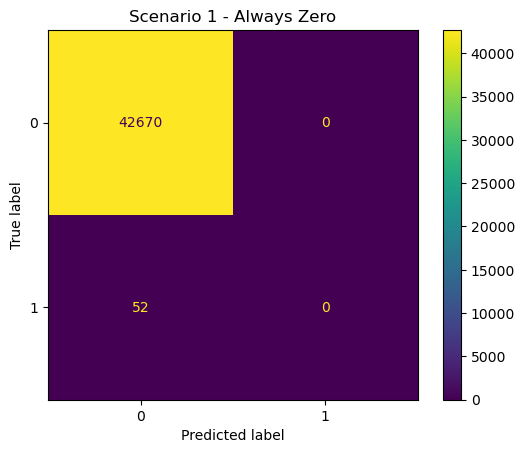

In [33]:
results_all = []

# Cenário 1: tudo zero
y_prob_s1 = np.zeros(len(y_test))   # probabilidade de fraude sempre zero
y_pred_s1 = np.zeros(len(y_test), dtype=int)

res_s1 = evaluate_predictions(
    y_true=y_test,
    y_pred=y_pred_s1,
    y_prob=y_prob_s1,
    amount=amount_test,
    scenario_name="Scenario 1 - Absurd",
    model_name="Always Zero",
    threshold=1.0,  # irrelevante aqui, mas deixamos registrado
    fn_loss_rate=1.0,
    fp_loss_rate=0.02
)

results_all.append(res_s1)

print(pd.DataFrame([res_s1]))
plot_confusion(y_test, y_pred_s1, "Scenario 1 - Always Zero")

### Cenário 2 (Ingênuo):

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

naive_models = {
    "LogisticRegression_Naive": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=5000, random_state=42))
    ]),
    
    "RandomForest_Naive": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    
    "ExtraTrees_Naive": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    
    "HistGradientBoosting_Naive": HistGradientBoostingClassifier(
        random_state=42
    )
}


LogisticRegression_Naive
             scenario                     model  threshold  accuracy  \
0  Scenario 2 - Naive  LogisticRegression_Naive        0.5  0.999181   

   precision    recall        f1   roc_auc    pr_auc     tn  fp  fn  tp  \
0   0.757576  0.480769  0.588235  0.964681  0.643561  42662   8  27  25   

   fn_cost  fp_cost  total_cost  n_fn  n_fp  
0  4044.04  513.931    4557.971    27     8  


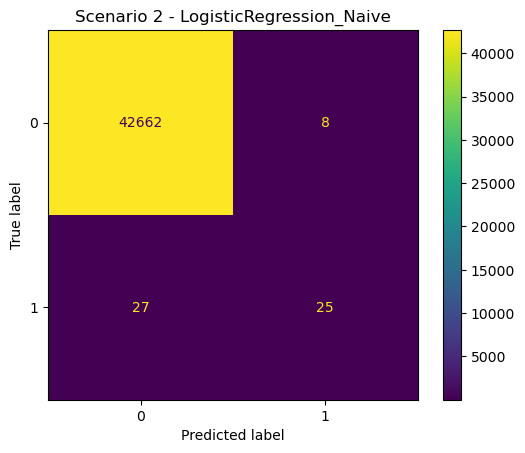

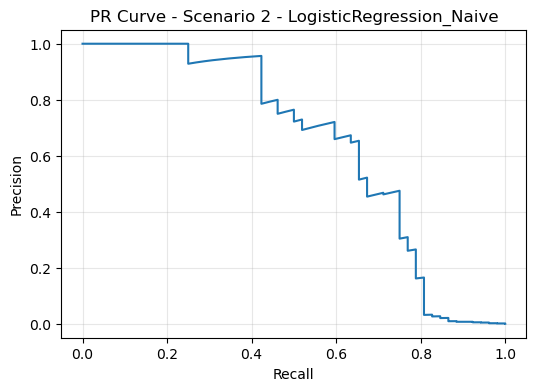

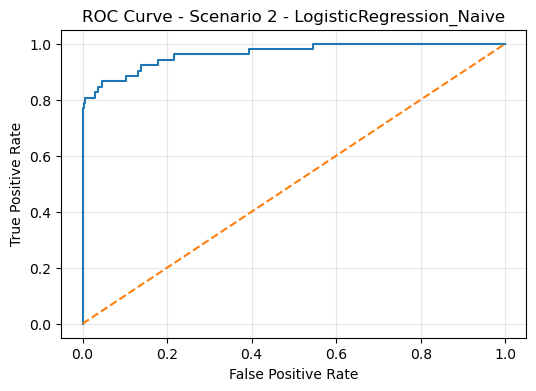


RandomForest_Naive
             scenario               model  threshold  accuracy  precision  \
0  Scenario 2 - Naive  RandomForest_Naive        0.5  0.999579   0.972222   

     recall        f1  roc_auc    pr_auc     tn  fp  fn  tp  fn_cost  \
0  0.673077  0.795455  0.93479  0.752455  42669   1  17  35  2706.43   

    fp_cost  total_cost  n_fn  n_fp  
0  513.8232   3220.2532    17     1  


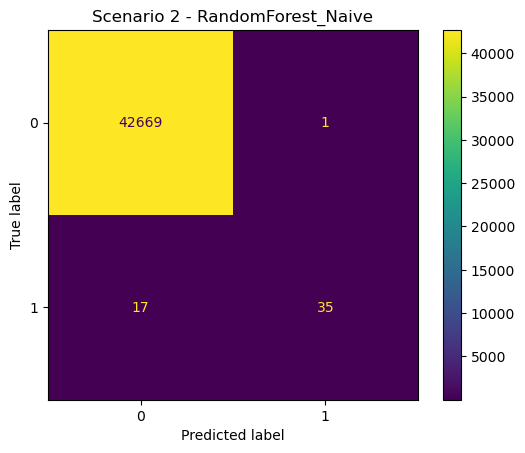

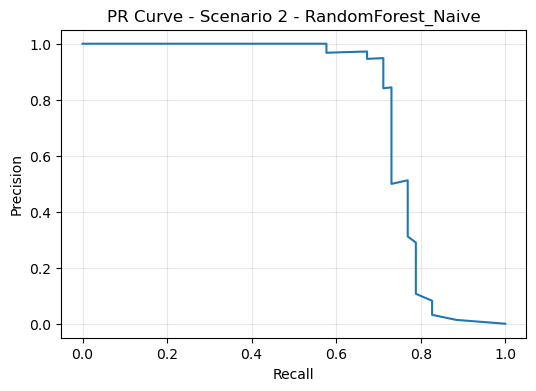

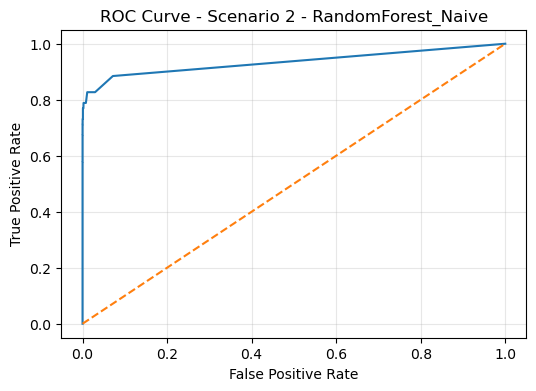


ExtraTrees_Naive
             scenario             model  threshold  accuracy  precision  \
0  Scenario 2 - Naive  ExtraTrees_Naive        0.5  0.999602        1.0   

     recall        f1   roc_auc    pr_auc     tn  fp  fn  tp  fn_cost  \
0  0.673077  0.804598  0.917384  0.764197  42670   0  17  35  2706.43   

   fp_cost  total_cost  n_fn  n_fp  
0      0.0     2706.43    17     0  


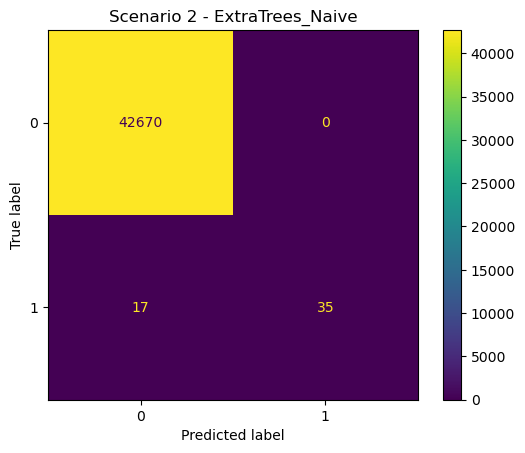

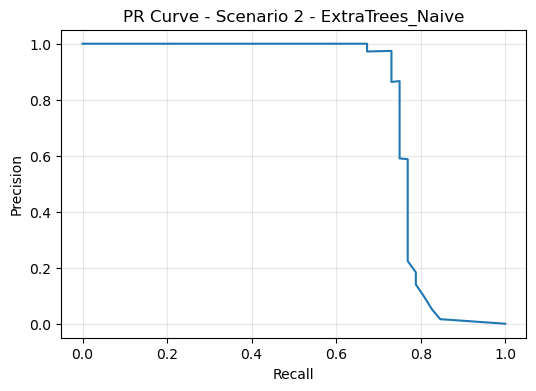

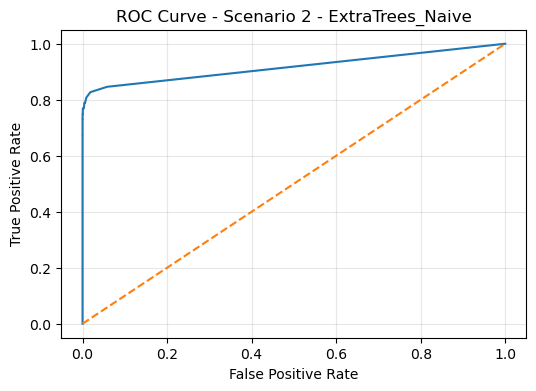


HistGradientBoosting_Naive
             scenario                       model  threshold  accuracy  \
0  Scenario 2 - Naive  HistGradientBoosting_Naive        0.5  0.999017   

   precision    recall        f1   roc_auc    pr_auc     tn  fp  fn  tp  \
0   0.608696  0.538462  0.571429  0.700625  0.413336  42652  18  24  28   

   fn_cost   fp_cost  total_cost  n_fn  n_fp  
0  4896.53  736.1106   5632.6406    24    18  


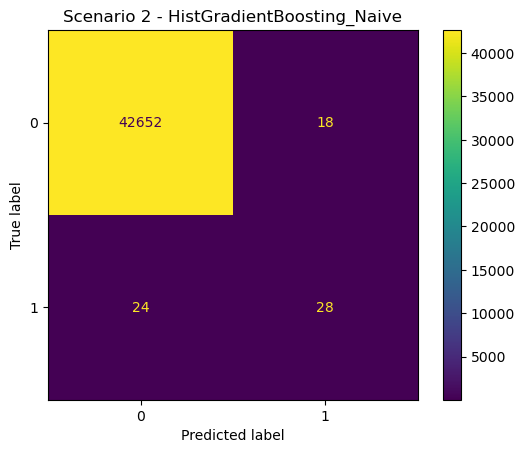

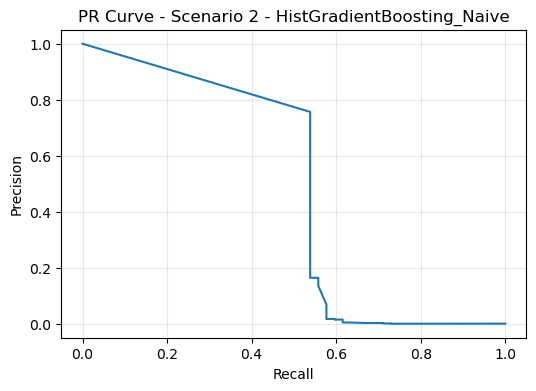

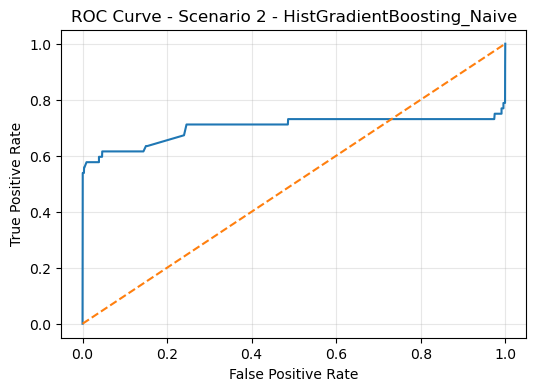

In [35]:
results_all = []

for model_name, model in naive_models.items():
    clf = clone(model)
    clf.fit(X_train, y_train)

    y_prob = clf.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    res = evaluate_predictions(
        y_true=y_test,
        y_pred=y_pred,
        y_prob=y_prob,
        amount=amount_test,
        scenario_name="Scenario 2 - Naive",
        model_name=model_name,
        threshold=0.5,
        fn_loss_rate=1.0,
        fp_loss_rate=0.02
    )

    results_all.append(res)

    print(f"\n{model_name}")
    print(pd.DataFrame([res]))

    plot_confusion(y_test, y_pred, f"Scenario 2 - {model_name}")
    plot_pr_curve(y_test, y_prob, f"PR Curve - Scenario 2 - {model_name}")
    plot_roc_curve(y_test, y_prob, f"ROC Curve - Scenario 2 - {model_name}")

### Cenário 3 (Robusto):
* split temporal já respeitado
* desbalanceamento tratado
* threshold escolhido por custo na validação
* avaliação final no teste
* Modelos
    * LogisticRegression com class_weight='balanced'
    * RandomForestClassifier com class_weight='balanced_subsample'
    * ExtraTreesClassifier com class_weight='balanced'
    * HistGradientBoostingClassifier sem class_weight

In [36]:
robust_models = {
    "LogisticRegression_Robust": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
    ]),
    
    "RandomForest_Robust": RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ),
    "ExtraTrees_Robust": ExtraTreesClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    "HistGradientBoosting_Robust": HistGradientBoostingClassifier(
        random_state=42
    )
}


LogisticRegression_Robust
Best threshold from validation: 0.9900
              scenario                      model  threshold  accuracy  \
0  Scenario 3 - Robust  LogisticRegression_Robust       0.99  0.998947   

   precision  recall        f1   roc_auc    pr_auc     tn  fp  fn  tp  \
0   0.549296    0.75  0.634146  0.977237  0.706915  42638  32  13  39   

   fn_cost    fp_cost  total_cost  n_fn  n_fp  
0   2372.4  1044.8562   3417.2562    13    32  


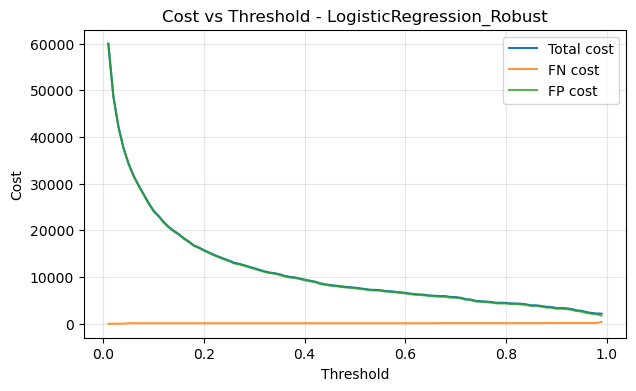

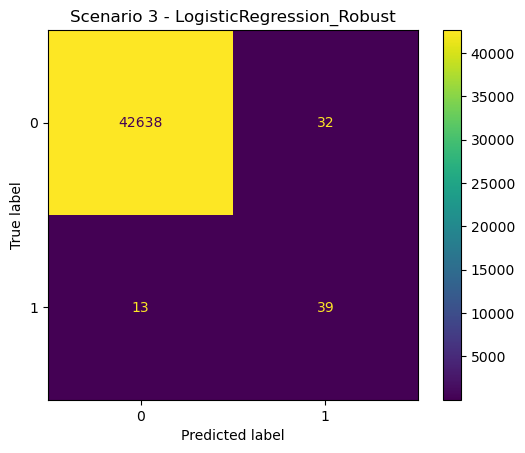

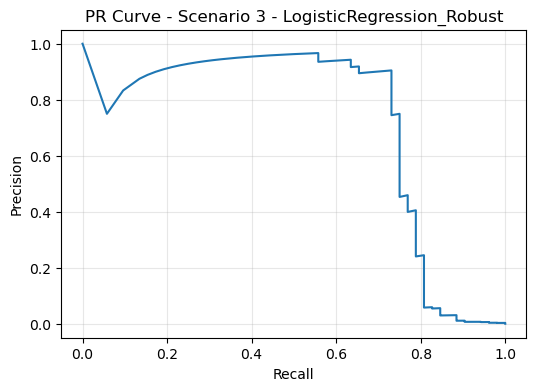

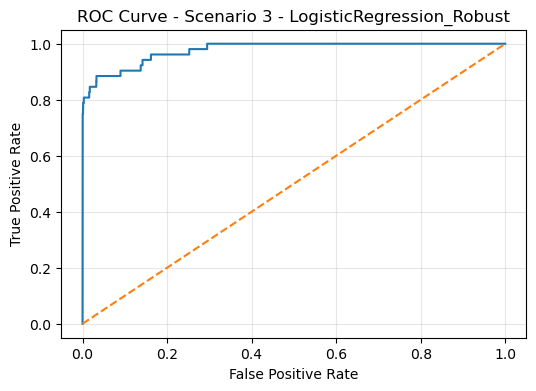


RandomForest_Robust
Best threshold from validation: 0.1000
              scenario                model  threshold  accuracy  precision  \
0  Scenario 3 - Robust  RandomForest_Robust        0.1  0.999415   0.764706   

   recall        f1  roc_auc    pr_auc     tn  fp  fn  tp  fn_cost  fp_cost  \
0    0.75  0.757282  0.91852  0.775299  42658  12  13  39   2372.4   14.075   

   total_cost  n_fn  n_fp  
0    2386.475    13    12  


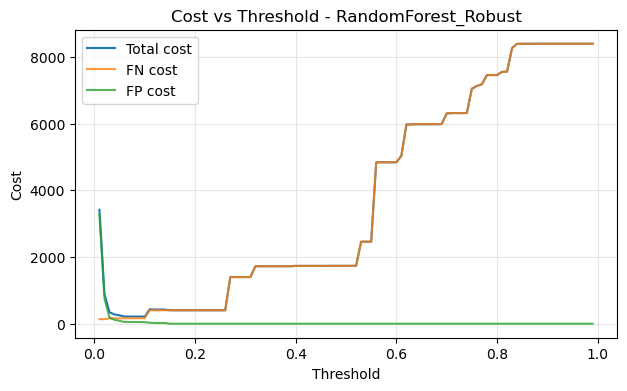

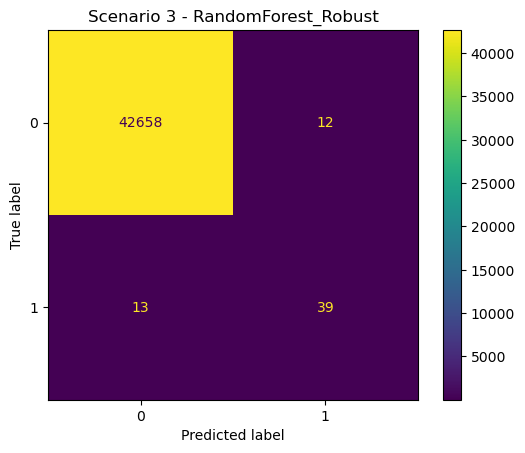

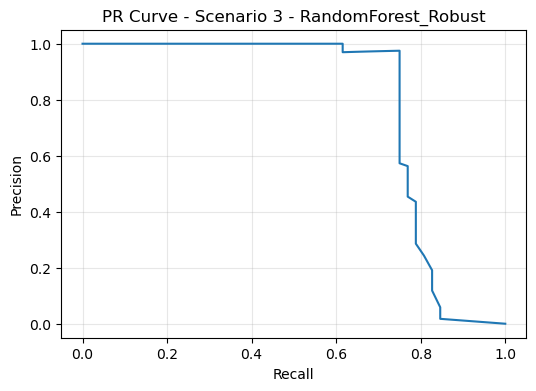

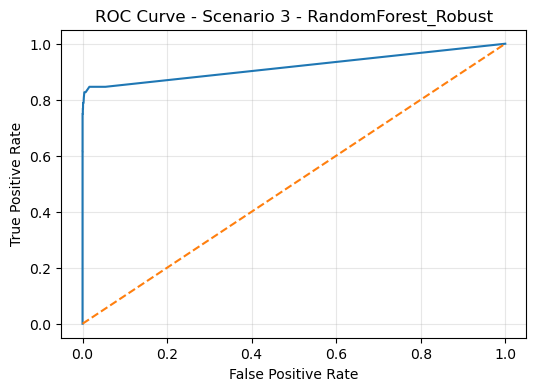


ExtraTrees_Robust
Best threshold from validation: 0.1600
              scenario              model  threshold  accuracy  precision  \
0  Scenario 3 - Robust  ExtraTrees_Robust       0.16  0.999462   0.795918   

   recall        f1   roc_auc    pr_auc     tn  fp  fn  tp  fn_cost   fp_cost  \
0    0.75  0.772277  0.927454  0.765292  42660  10  13  39   2372.4  529.7206   

   total_cost  n_fn  n_fp  
0   2902.1206    13    10  


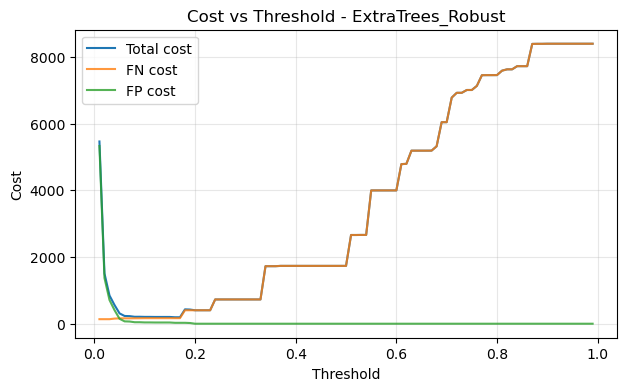

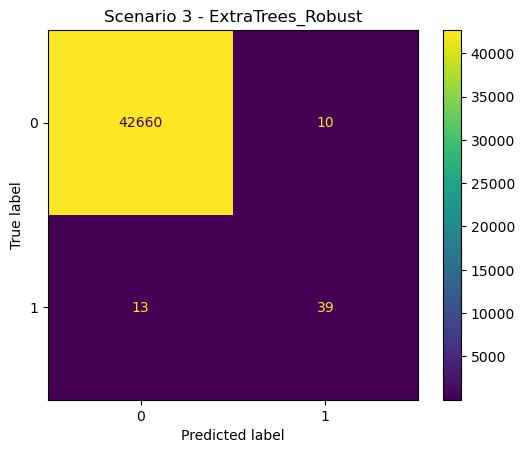

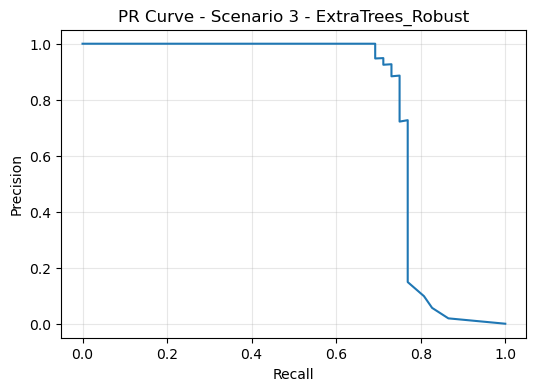

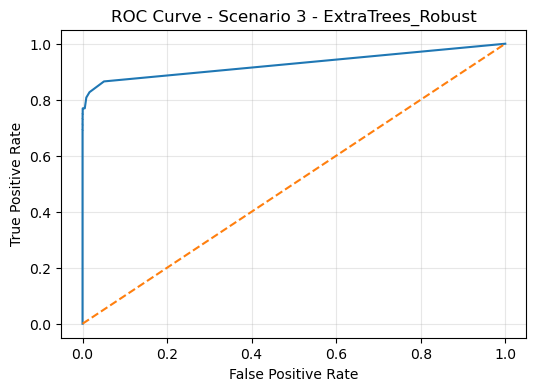


HistGradientBoosting_Robust
Best threshold from validation: 0.8600
              scenario                        model  threshold  accuracy  \
0  Scenario 3 - Robust  HistGradientBoosting_Robust       0.86  0.999157   

   precision    recall        f1   roc_auc    pr_auc     tn  fp  fn  tp  \
0        0.7  0.538462  0.608696  0.700625  0.413336  42658  12  24  28   

   fn_cost   fp_cost  total_cost  n_fn  n_fp  
0  4896.53  731.1306   5627.6606    24    12  


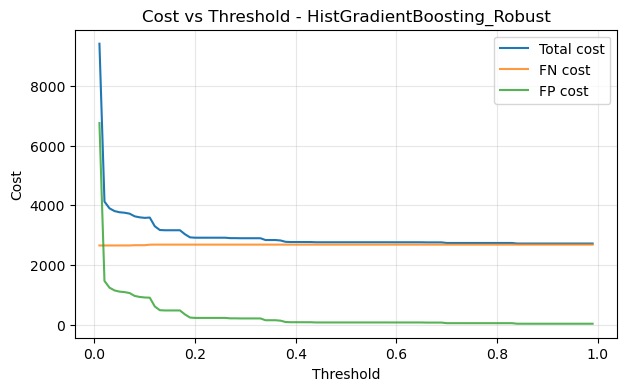

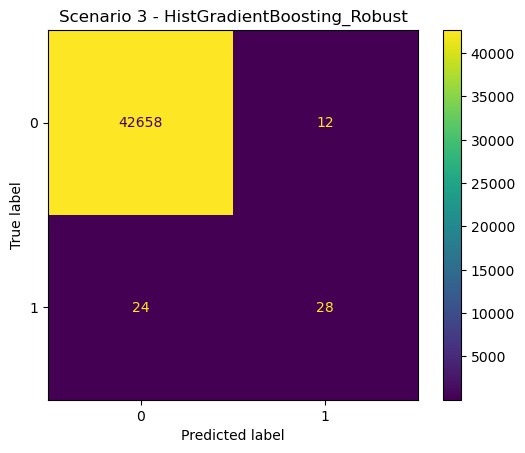

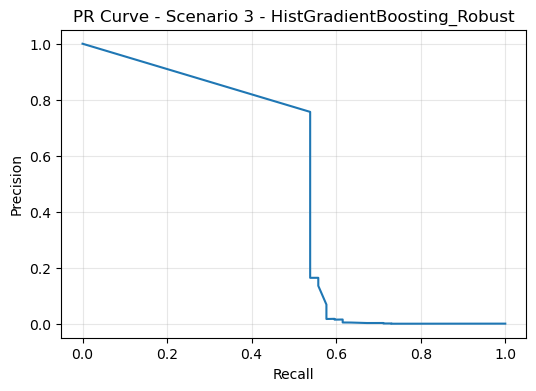

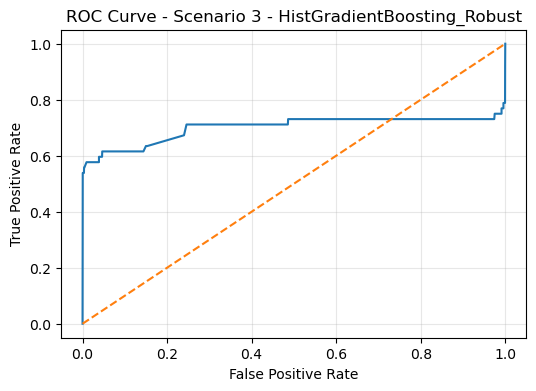

In [37]:
threshold_histories = {}

for model_name, model in robust_models.items():
    clf = clone(model)
    clf.fit(X_train, y_train)

    # Probabilidades na validação
    y_val_prob = clf.predict_proba(X_val)[:, 1]

    # Escolher threshold ótimo pelo custo
    best_threshold, history_df = find_best_threshold_by_cost(
        y_true=y_val,
        y_prob=y_val_prob,
        amount=amount_val,
        fn_loss_rate=1.0,
        fp_loss_rate=0.02,
        thresholds=np.linspace(0.01, 0.99, 99)
    )

    threshold_histories[model_name] = history_df

    # Aplicar no teste
    y_test_prob = clf.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_prob >= best_threshold).astype(int)

    res = evaluate_predictions(
        y_true=y_test,
        y_pred=y_test_pred,
        y_prob=y_test_prob,
        amount=amount_test,
        scenario_name="Scenario 3 - Robust",
        model_name=model_name,
        threshold=best_threshold,
        fn_loss_rate=1.0,
        fp_loss_rate=0.02
    )

    results_all.append(res)

    print(f"\n{model_name}")
    print(f"Best threshold from validation: {best_threshold:.4f}")
    print(pd.DataFrame([res]))

    plot_cost_vs_threshold(history_df, f"Cost vs Threshold - {model_name}")
    plot_confusion(y_test, y_test_pred, f"Scenario 3 - {model_name}")
    plot_pr_curve(y_test, y_test_prob, f"PR Curve - Scenario 3 - {model_name}")
    plot_roc_curve(y_test, y_test_prob, f"ROC Curve - Scenario 3 - {model_name}")

### Comparação entre os cenários

In [38]:
results_df = pd.DataFrame(results_all)

cols_order = [
    "scenario", "model", "threshold",
    "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc",
    "tn", "fp", "fn", "tp",
    "fn_cost", "fp_cost", "total_cost"
]

results_df = results_df[cols_order].sort_values(
    by=["scenario", "total_cost", "pr_auc"],
    ascending=[True, True, False]
)

print(results_df)

              scenario                        model  threshold  accuracy  \
2   Scenario 2 - Naive             ExtraTrees_Naive       0.50  0.999602   
1   Scenario 2 - Naive           RandomForest_Naive       0.50  0.999579   
0   Scenario 2 - Naive     LogisticRegression_Naive       0.50  0.999181   
3   Scenario 2 - Naive   HistGradientBoosting_Naive       0.50  0.999017   
5  Scenario 3 - Robust          RandomForest_Robust       0.10  0.999415   
6  Scenario 3 - Robust            ExtraTrees_Robust       0.16  0.999462   
4  Scenario 3 - Robust    LogisticRegression_Robust       0.99  0.998947   
7  Scenario 3 - Robust  HistGradientBoosting_Robust       0.86  0.999157   

   precision    recall        f1   roc_auc    pr_auc     tn  fp  fn  tp  \
2   1.000000  0.673077  0.804598  0.917384  0.764197  42670   0  17  35   
1   0.972222  0.673077  0.795455  0.934790  0.752455  42669   1  17  35   
0   0.757576  0.480769  0.588235  0.964681  0.643561  42662   8  27  25   
3   0.608696  0

In [39]:
results_df = pd.DataFrame(results_all)

cols_order = [
    "scenario", "model", "threshold",
    "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc",
    "tn", "fp", "fn", "tp",
    "fn_cost", "fp_cost", "total_cost"
]

results_df = results_df[cols_order].sort_values(
    by=["scenario", "total_cost", "pr_auc"],
    ascending=[True, True, False]
)

print(results_df)

              scenario                        model  threshold  accuracy  \
2   Scenario 2 - Naive             ExtraTrees_Naive       0.50  0.999602   
1   Scenario 2 - Naive           RandomForest_Naive       0.50  0.999579   
0   Scenario 2 - Naive     LogisticRegression_Naive       0.50  0.999181   
3   Scenario 2 - Naive   HistGradientBoosting_Naive       0.50  0.999017   
5  Scenario 3 - Robust          RandomForest_Robust       0.10  0.999415   
6  Scenario 3 - Robust            ExtraTrees_Robust       0.16  0.999462   
4  Scenario 3 - Robust    LogisticRegression_Robust       0.99  0.998947   
7  Scenario 3 - Robust  HistGradientBoosting_Robust       0.86  0.999157   

   precision    recall        f1   roc_auc    pr_auc     tn  fp  fn  tp  \
2   1.000000  0.673077  0.804598  0.917384  0.764197  42670   0  17  35   
1   0.972222  0.673077  0.795455  0.934790  0.752455  42669   1  17  35   
0   0.757576  0.480769  0.588235  0.964681  0.643561  42662   8  27  25   
3   0.608696  0

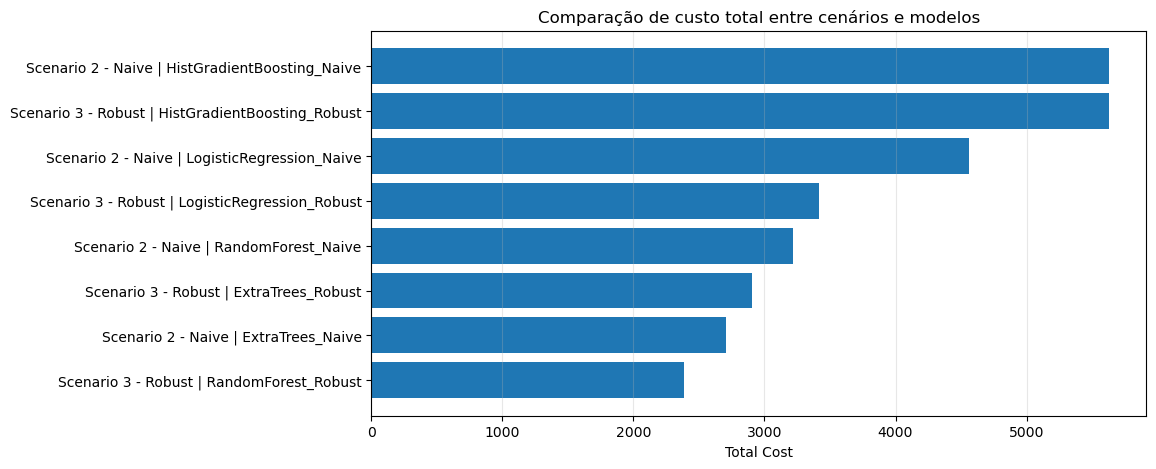

In [42]:
plot_df = results_display.sort_values("total_cost")

plt.figure(figsize=(10, 5))
plt.barh(plot_df["scenario"] + " | " + plot_df["model"], plot_df["total_cost"])
plt.xlabel("Total Cost")
plt.title("Comparação de custo total entre cenários e modelos")
plt.grid(axis='x', alpha=0.3)
plt.show()

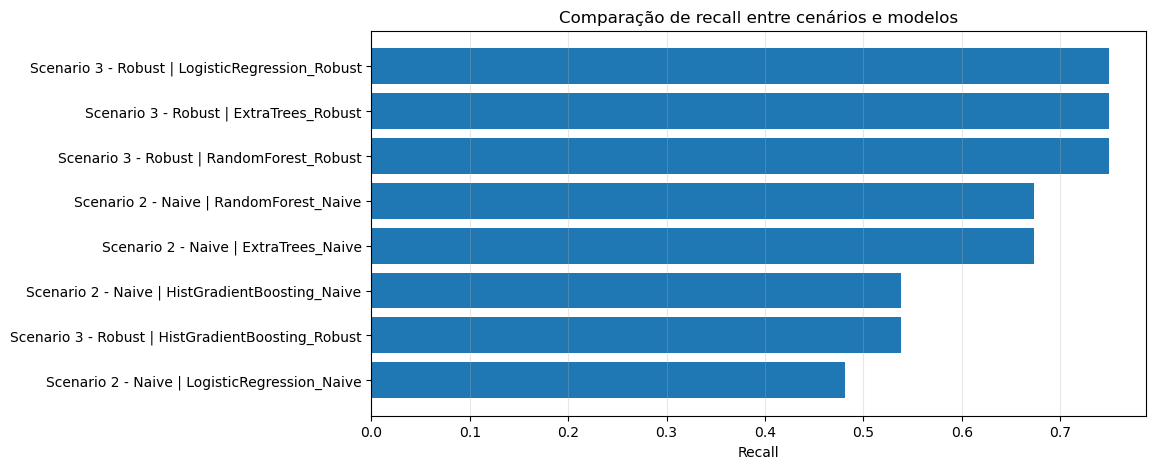

In [43]:
# Recall de fraude
plot_df = results_display.sort_values("recall", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["scenario"] + " | " + plot_df["model"], plot_df["recall"])
plt.xlabel("Recall")
plt.title("Comparação de recall entre cenários e modelos")
plt.grid(axis='x', alpha=0.3)
plt.show()

# Conclusão

Este projeto teve como objetivo analisar detecção de fraude não apenas como um problema de classificação, mas como um problema de **tomada de decisão sob custo e desbalanceamento severo**.

A partir dos experimentos realizados, algumas conclusões importantes podem ser destacadas.

---

## 1. Acurácia é uma métrica insuficiente em problemas desbalanceados

O Cenário 1 (baseline absurdo) evidenciou de forma clara uma armadilha clássica:

- o modelo apresentou **acurácia extremamente alta (~99.8%)**;
- porém **não detectou nenhuma fraude (recall = 0)**;
- resultando no **maior prejuízo financeiro entre todos os cenários**.

Isso demonstra que, em problemas com classes raras, **métricas tradicionais podem ser enganosas se analisadas isoladamente**.

---

## 2. Modelos ingênuos podem parecer bons, mas não são necessariamente ótimos para decisão

No Cenário 2, modelos tradicionais apresentaram bons resultados em métricas como ROC-AUC e acurácia. No entanto:

- o desempenho variou significativamente em termos de custo;
- modelos com bom ranking (ROC-AUC alto) não necessariamente tiveram melhor desempenho econômico;
- o threshold padrão (0.5) mostrou-se inadequado para o problema.

Um ponto relevante foi o desempenho do **ExtraTrees_Naive**, que apresentou:
- zero falsos positivos;
- bom recall;
- baixo custo total.

Isso indica que, mesmo sem ajustes sofisticados, alguns modelos já podem produzir resultados competitivos — mas sem garantia de serem os melhores sob uma ótica de negócio.

---

## 3. Modelagem robusta melhora a decisão, mas não de forma uniforme

No Cenário 3, ao incorporar:

- divisão temporal,
- tratamento de desbalanceamento,
- e ajuste de threshold orientado a custo,

observou-se uma melhora relevante em alguns modelos.

O principal destaque foi o **RandomForest_Robust**, que apresentou:

- maior recall (0.75);
- redução significativa de falsos negativos;
- **menor custo total entre todos os modelos testados**.

Isso evidencia que:

> **otimizar o modelo para custo, e não apenas para classificação, leva a decisões mais eficientes do ponto de vista financeiro.**

---

## 4. Nem toda “melhoria técnica” resulta em ganho econômico

Um ponto importante observado foi que:

- o **ExtraTrees_Robust** teve desempenho inferior ao seu equivalente ingênuo;
- o aumento de recall veio acompanhado de aumento de falsos positivos;
- o custo adicional de FP superou o benefício da redução de FN.

Isso reforça que:

> **melhorias em métricas de ML nem sempre se traduzem em melhoria de negócio.**

Cada modelo deve ser avaliado no contexto da função de custo.

---

## 5. ROC-AUC alto não garante melhor decisão

O caso da **LogisticRegression_Robust** foi particularmente interessante:

- apresentou ROC-AUC muito elevado (~0.97);
- teve recall competitivo;
- porém gerou muitos falsos positivos, aumentando o custo total.

Isso mostra a diferença entre:

- **qualidade de ranking (discriminação)**  
vs  
- **qualidade da decisão (threshold + custo)**

---

## 6. A importância da métrica de custo

A introdução de uma função de custo foi fundamental para:

- diferenciar modelos que pareciam similares em métricas tradicionais;
- revelar trade-offs entre FN e FP;
- alinhar a avaliação com o impacto financeiro real.

Sem essa métrica, conclusões importantes do projeto não seriam visíveis.

---

## 7. Conclusão geral

Os resultados mostram que:

- modelagem de fraude não deve ser tratada como um problema de classificação padrão;
- decisões baseadas apenas em métricas tradicionais podem levar a prejuízos significativos;
- abordagens robustas, orientadas a custo, podem melhorar significativamente o desempenho operacional;
- porém, **não existe uma solução única** — o desempenho depende do modelo e do contexto de decisão.

---

## 8. Principal aprendizado

A principal lição deste projeto é:

> **Em problemas reais de Ciência de Dados, especialmente em Finanças, entender os dados, o contexto e o custo dos erros é tão importante quanto escolher o modelo.**

---

## 9. Próximos passos

Como continuidade natural deste trabalho, algumas extensões relevantes incluem:

- calibração de probabilidades;
- tuning de hiperparâmetros orientado a custo;
- refinamento da escolha de threshold;
- análise de sensibilidade para diferentes hipóteses de custo;
- validação temporal mais robusta;
- teste de modelos adicionais como XGBoost e LightGBM.

---

Este projeto demonstra que, mais do que encontrar o melhor modelo, o objetivo deve ser construir **uma política de decisão consistente, interpretável e alinhada ao risco financeiro**.